# Sprint 01 — US 1.3 : Couche SILVER (nettoyage, conformation, intégration)

Transformation `bronze → silver` : dédoublonnage, **imputation** des NaN (interpolation
temporelle, *maintenance-aware*), **flag des outliers** (IQR, conservés), **flag des
fenêtres de maintenance**, et **enrichissement** par la dimension machine
(`model`/`criticality`). Tables écrites dans le schéma `silver` (PostgreSQL).

> **Prérequis** : base démarrée + `bronze` alimenté (`00_acquisition`).

## 1. Construction de la couche silver

Équivalent notebook de `uv run indusense-silver` (lit bronze, écrit silver).

In [1]:
from indusense.data import silver

meta = silver.run()
t = meta['telemetry']
print(f"telemetry : {t['n_lignes']} lignes")
print(f"  doublons retirés : {t['n_doublons_supprimes']}")
print(f"  relevés en maintenance : {t['n_relevés_maintenance']}")
print(f"  valeurs imputées : {meta['n_imputes_total']} | NaN résiduels (en maintenance) : {t['n_nan_residuels']}")
print(f"  outliers flaggés : {t['n_outliers_flagges']}")
print(f"incident : {meta['n_incidents']} | machine : {meta['n_machines']} | maintenance : {meta['n_maintenances']}")

telemetry : 134280 lignes
  doublons retirés : 1346
  relevés en maintenance : 3667
  valeurs imputées : 2752 | NaN résiduels (en maintenance) : 60
  outliers flaggés : {'temperature_c': 278, 'pressure_bar': 1532, 'voltage_mean_v': 639, 'rotation_mean_rpm': 864}
incident : 1245 | machine : 15 | maintenance : 1562


## 2. Viewers (US 1.3) — boxplots & bilan du nettoyage


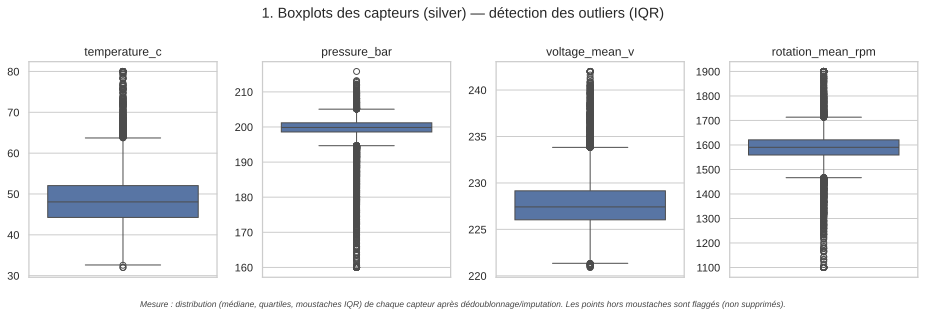

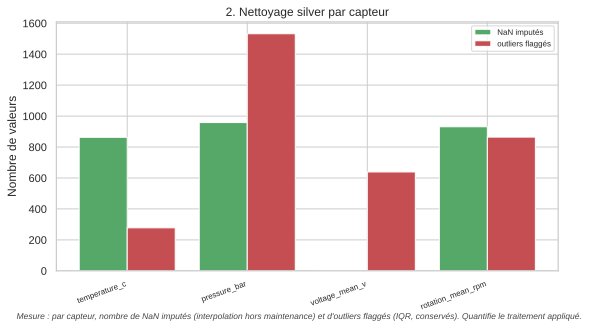

In [2]:
from IPython.display import SVG, display

from indusense import config

run_dir = sorted(p for p in config.SILVER_DIR.glob('2*') if p.is_dir())[-1]
for fig in sorted((run_dir / 'figures').glob('*.svg')):
    display(SVG(filename=str(fig)))

## 3. Vérification : nettoyage cohérent & enrichissement

On relit `silver.telemetry` et on vérifie : (a) plus de NaN **hors** maintenance,
(b) l'enrichissement `model`, (c) le profil **par modèle** (validation de la jointure).

In [3]:
import pandas as pd
from sqlalchemy import text
from indusense.data.db import get_engine

cols = 'model, during_maintenance, temperature_c, rotation_mean_rpm, pieces_produced'
tel = pd.read_sql(text(f'SELECT {cols} FROM silver.telemetry'), get_engine())
op = tel[~tel['during_maintenance']]
print('NaN hors maintenance :', int(op[['temperature_c','rotation_mean_rpm']].isna().sum().sum()))
print('NaN en maintenance (conservés) :', int(tel.loc[tel['during_maintenance'], 'temperature_c'].isna().sum()))
print('Moyennes capteurs par modèle (hors maintenance) :')
op.groupby('model')[['temperature_c','rotation_mean_rpm','pieces_produced']].mean().round(1)

NaN hors maintenance : 0
NaN en maintenance (conservés) : 19
Moyennes capteurs par modèle (hors maintenance) :


,temperature_c,rotation_mean_rpm,pieces_produced
model,,,
InduPress-X1,51.7,1620.8,59.8
InduPress-X2,48.0,1589.0,48.5
InduPress-X3,48.3,1573.6,47.6
InduPress-Z1,46.2,1583.9,47.3


➡️ **Conclusions**

- **Silver propre & traçable** : doublons retirés, NaN **opérationnels** imputés
  (interpolation par segment inter-maintenance), NaN **en maintenance conservés**
  (non opérationnels), outliers **flaggés** (`*_is_outlier`) sans destruction.
- **Intégration** : `model`/`criticality` joints → analyses **par type de machine**
  désormais possibles (l'`InduPress-X1` se distingue : plus chaud, plus rapide, plus productif).
- **Reporté au gold** : usage des fenêtres de maintenance (exclusion / features
  `time_since_last_maintenance`) et choix de traitement des outliers — cf. US 1.4/1.5.